# Model Evaluation and Performance Comparison

This notebook evaluates and compares all trained models for brain tumor MRI classification.

Models included:
- Simple CNN (Baseline)
- MobileNet Baseline
- MobileNet Partial Unfreeze
- MobileNet Block Unfreeze
- ResNet50 Baseline
- ResNet50 Partial Fine-Tuning
- ResNet50 Deeper Fine-Tuning

Evaluation is performed on the raw test dataset.

## 1) Import Libraries

This section imports all required libraries for loading trained models, running evaluation, generating metrics, and visualizing results.

In [13]:
import torch
import cv2
import torch.nn.functional as F
from PIL import Image
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.models as models
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

sys.path.append(os.path.abspath(".."))

from src.dataset import BrainTumorDataset
from src.transforms import test_transform
from src.simple_cnn import SimpleCNN

## 2) Configuration

This section defines paths, device configuration, batch size, and class labels used during evaluation.

In [14]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
TEST_DIR = "../data/raw/test"
CLASS_NAMES = ["glioma","meningioma","no_tumor","pituitary"]
NUM_CLASSES = len(CLASS_NAMES)

CLASS_TO_IDX = {
    "glioma": 0,
    "meningioma": 1,
    "no_tumor": 2,
    "pituitary": 3
}

MODEL_PATHS = {
    "Simple CNN": "../models/baseline_cnn.pth",
    "MobileNet Baseline": "../models/mobilenet_baseline.pth",
    "MobileNet Partial Unfreeze": "../models/mobilenet_partial_unfreeze.pth",
    "MobileNet Block Unfreeze": "../models/mobilenet_block_unfreeze.pth",
    "ResNet50 Baseline": "../models/resnet50_baseline.pth",
    "ResNet50 Partial Fine-Tuning": "../models/resnet50_partial_finetuning.pth",
    "ResNet50 Deeper Fine-Tuning": "../models/resnet50_deep_finetuning.pth"
}

print("Device:", DEVICE)

Device: cuda


## 3) Load Test Dataset

This section prepares the processed test dataset for final evaluation.

The evaluation uses only test preprocessing without augmentation.

In [15]:
test_root = Path(TEST_DIR)
image_paths = []
labels = []

for class_name in CLASS_NAMES:
    class_folder = test_root / class_name
    for img_path in class_folder.glob("*"):
        image_paths.append(str(img_path))
        labels.append(CLASS_TO_IDX[class_name])

test_dataset = BrainTumorDataset(
    image_paths=image_paths,
    labels=labels,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test samples:", len(test_dataset))

Test samples: 1000


## 4) Model Loader

This function reconstructs the correct architecture based on the selected experiment and loads corresponding trained weights.

The architecture is automatically selected according to the model name.

In [16]:
def load_model(name, path):

    if name == "Simple CNN":
        model = SimpleCNN()

    elif "MobileNet" in name:
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)

    elif "ResNet50" in name:
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    else:
        raise ValueError(f"Unknown model name: {name}")

    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    return model

## 5) Evaluation Function

This function performs model evaluation by generating predictions and computing performance metrics.

In [17]:
def evaluate(model):

    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(DEVICE)
            out = model(x)
            prob = torch.softmax(out, dim=1)
            pred = torch.argmax(prob, dim=1)
            y_true.extend(y.numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

## 6) Metrics & Confusion Matrix & ROC

This section calculates evaluation metrics and visualizes model performance using a confusion matrix.

We use:

- Accuracy
- Precision
- Recall
- F1-score

In [18]:
def compute_metrics(y_true, y_pred, y_prob):

    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1": f1_score(y_true, y_pred, average="weighted"),
        "AUC": roc_auc_score(y_true_bin, y_prob, multi_class="ovr")
    }

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.show()

def plot_roc(y_true, y_prob, title):
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(8,6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'--')
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

In [19]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_image, class_idx=None):

        self.model.eval()

        output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        loss = output[0, class_idx]

        self.model.zero_grad()
        loss.backward()

        grads = self.gradients
        activations = self.activations

        weights = torch.mean(grads, dim=(2,3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1)

        cam = torch.relu(cam)
        cam = cam[0].detach().cpu().numpy()

        cam = cv2.resize(cam, (224,224))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam, class_idx

## 7)  Evaluate All Models
This section runs evaluation on all trained models and stores their performance for final comparison.


Model: Simple CNN


/tmp/ipykernel_318284/2902937036.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))


              precision    recall  f1-score   support

      glioma       0.90      0.64      0.74       254
  meningioma       0.69      0.62      0.65       306
    no_tumor       0.65      0.99      0.79       140
   pituitary       0.87      0.97      0.91       300

    accuracy                           0.78      1000
   macro avg       0.78      0.80      0.78      1000
weighted avg       0.79      0.78      0.77      1000



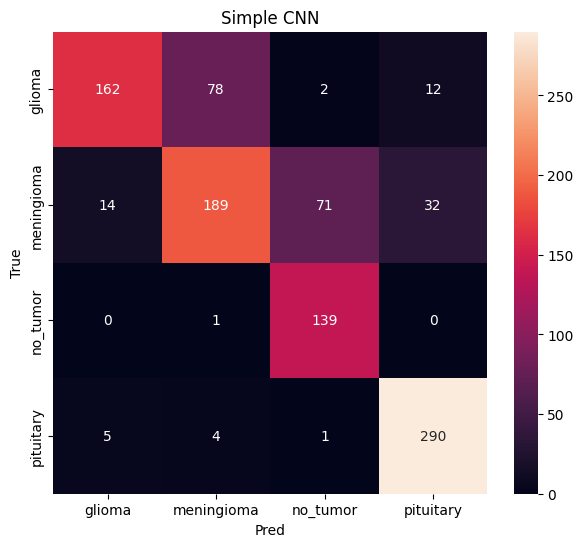

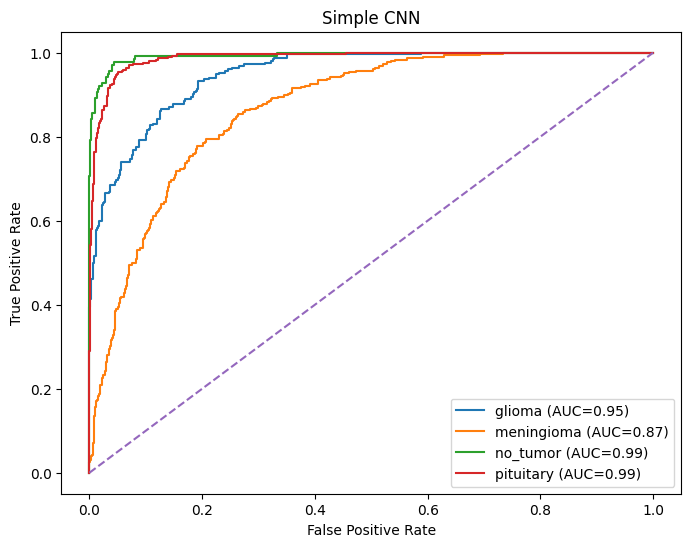


Model: MobileNet Baseline


/tmp/ipykernel_318284/2902937036.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))


              precision    recall  f1-score   support

      glioma       0.83      0.71      0.77       254
  meningioma       0.69      0.53      0.60       306
    no_tumor       0.59      0.96      0.73       140
   pituitary       0.84      0.90      0.87       300

    accuracy                           0.75      1000
   macro avg       0.74      0.77      0.74      1000
weighted avg       0.76      0.75      0.74      1000



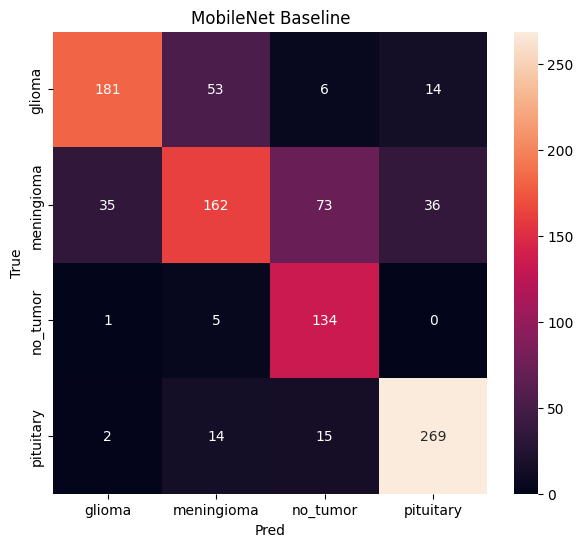

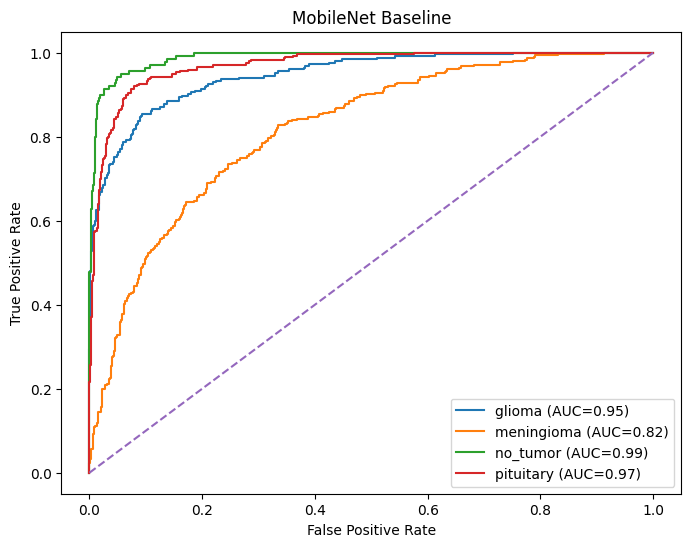


Model: MobileNet Partial Unfreeze


/tmp/ipykernel_318284/2902937036.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))


              precision    recall  f1-score   support

      glioma       0.95      0.86      0.90       254
  meningioma       0.87      0.86      0.86       306
    no_tumor       0.89      1.00      0.94       140
   pituitary       0.94      0.97      0.96       300

    accuracy                           0.91      1000
   macro avg       0.91      0.92      0.92      1000
weighted avg       0.92      0.91      0.91      1000



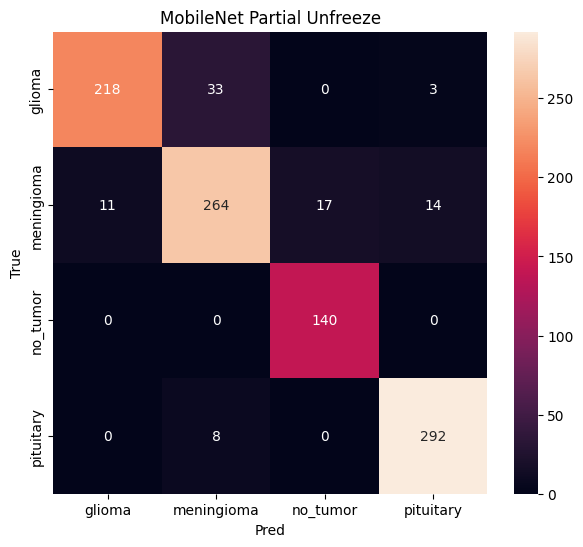

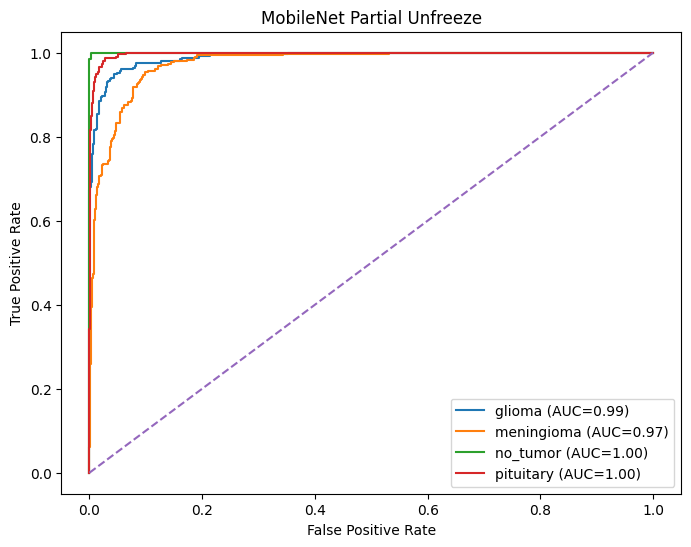


Model: MobileNet Block Unfreeze


/tmp/ipykernel_318284/2902937036.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))


              precision    recall  f1-score   support

      glioma       0.96      0.87      0.91       254
  meningioma       0.88      0.89      0.88       306
    no_tumor       0.93      1.00      0.97       140
   pituitary       0.95      0.98      0.96       300

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



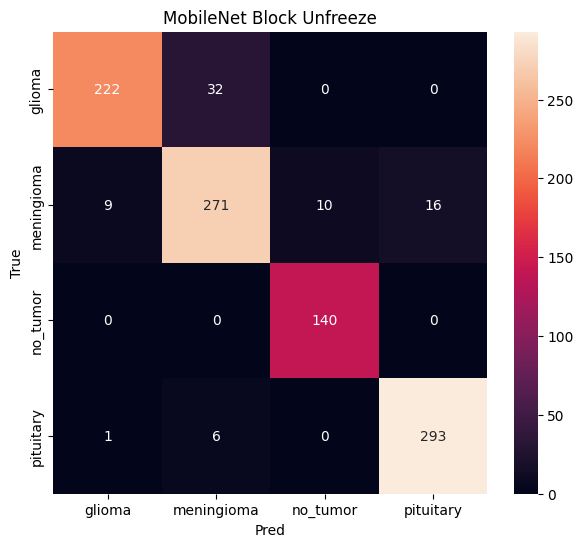

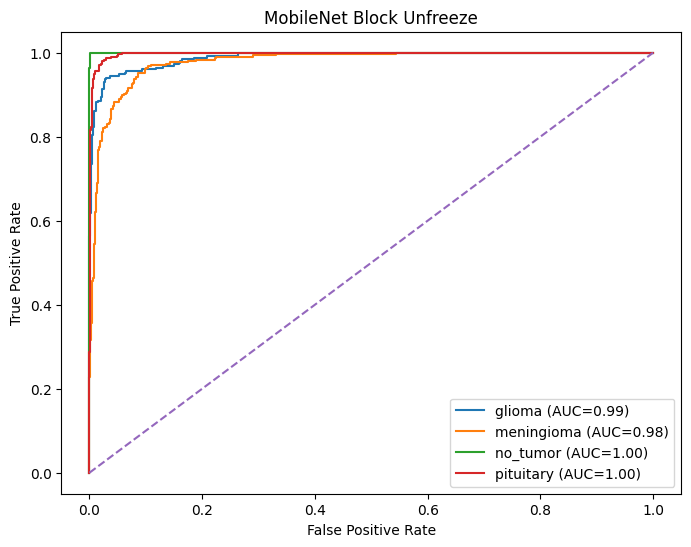


Model: ResNet50 Baseline


/tmp/ipykernel_318284/2902937036.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))


              precision    recall  f1-score   support

      glioma       0.81      0.71      0.76       254
  meningioma       0.68      0.57      0.62       306
    no_tumor       0.65      0.96      0.78       140
   pituitary       0.88      0.91      0.89       300

    accuracy                           0.76      1000
   macro avg       0.75      0.79      0.76      1000
weighted avg       0.77      0.76      0.76      1000



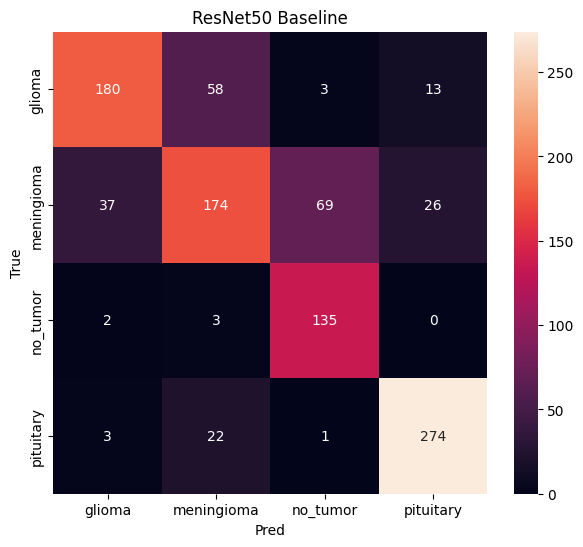

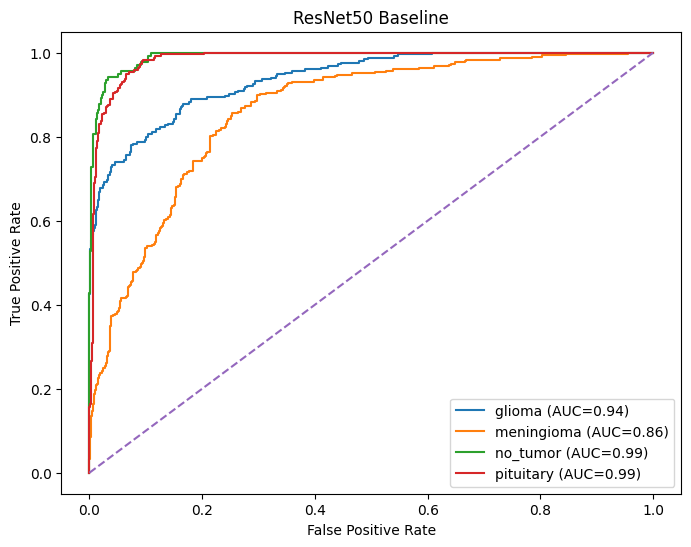


Model: ResNet50 Partial Fine-Tuning


/tmp/ipykernel_318284/2902937036.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))


              precision    recall  f1-score   support

      glioma       0.97      0.98      0.98       254
  meningioma       0.98      0.97      0.97       306
    no_tumor       0.99      1.00      0.99       140
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



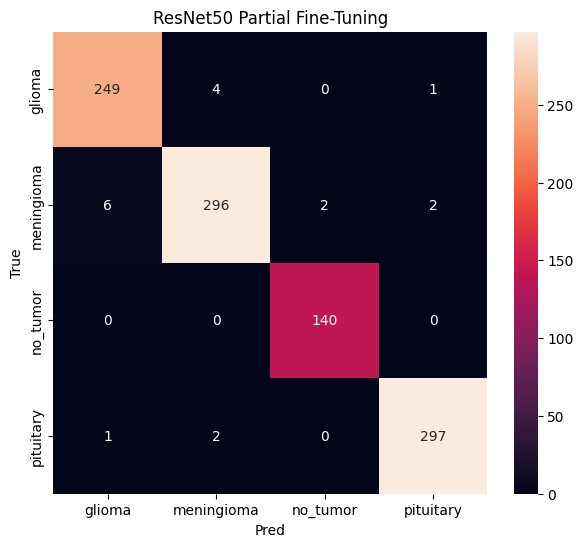

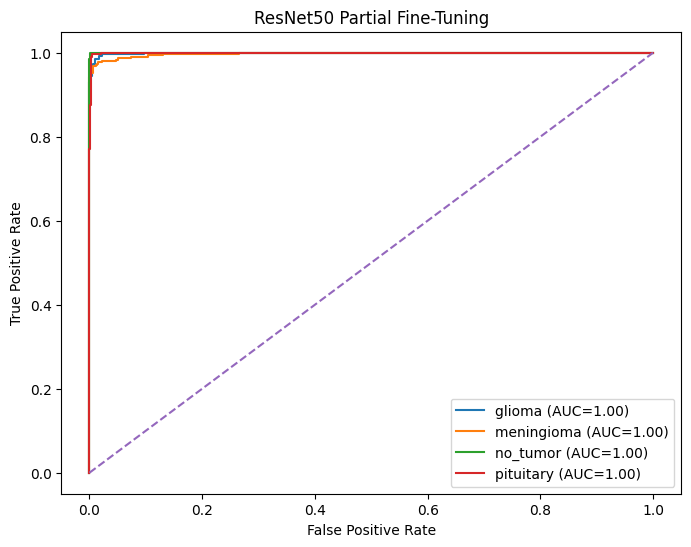


Model: ResNet50 Deeper Fine-Tuning


/tmp/ipykernel_318284/2902937036.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))


              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       254
  meningioma       0.98      0.99      0.98       306
    no_tumor       0.98      1.00      0.99       140
   pituitary       1.00      0.99      0.99       300

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



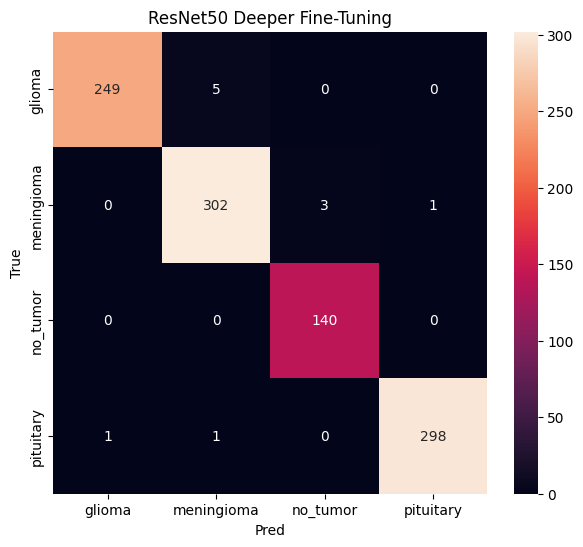

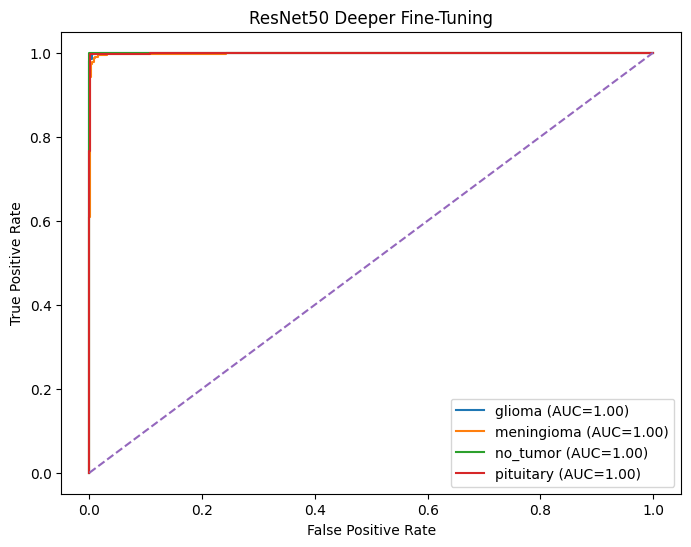

In [20]:
results = []

best_model = None
best_score = 0

for name, path in MODEL_PATHS.items():

    print("\n", "="*60)
    print("Model:", name)

    model = load_model(name, path)

    y_true, y_pred, y_prob = evaluate(model)
    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["Model"] = name

    results.append(metrics)

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    plot_cm(y_true, y_pred, name)
    plot_roc(y_true, y_prob, name)

    if metrics["F1"] > best_score:
        best_score = metrics["F1"]
        best_model = name
        best_model_obj = model

## 8) Model Comparison

In [21]:
df = pd.DataFrame(results)
df = df[["Model","Accuracy","Precision","Recall","F1","AUC"]]
print(df)
print("========================================")
print(" BEST MODEL:", best_model)
print(" BEST F1 SCORE:", best_score)

                          Model  Accuracy  Precision  Recall        F1  \
0                    Simple CNN     0.780   0.791803   0.780  0.774007   
1            MobileNet Baseline     0.746   0.757032   0.746  0.740693   
2    MobileNet Partial Unfreeze     0.914   0.915001   0.914  0.913387   
3      MobileNet Block Unfreeze     0.926   0.926553   0.926  0.925570   
4             ResNet50 Baseline     0.763   0.766606   0.763  0.758055   
5  ResNet50 Partial Fine-Tuning     0.982   0.982003   0.982  0.981978   
6   ResNet50 Deeper Fine-Tuning     0.989   0.989083   0.989  0.989006   

        AUC  
0  0.949853  
1  0.930922  
2  0.990288  
3  0.991074  
4  0.944052  
5  0.999005  
6  0.999386  
 BEST MODEL: ResNet50 Deeper Fine-Tuning
 BEST F1 SCORE: 0.9890058740075895


## 9) Grad-CAM Visualization

Grad-CAM is used to visualize which regions of the MRI image influenced the model prediction.

Since ResNet50 Deeper Fine-Tuning achieved the best performance, we apply Grad-CAM to this model.

/tmp/ipykernel_318284/2902937036.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))


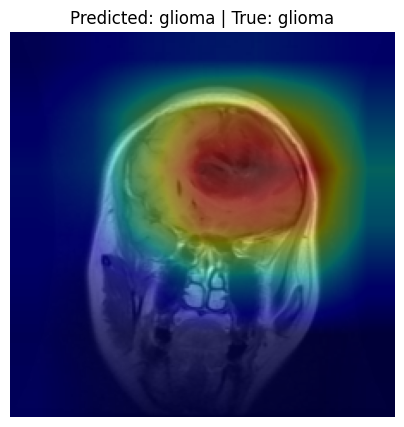

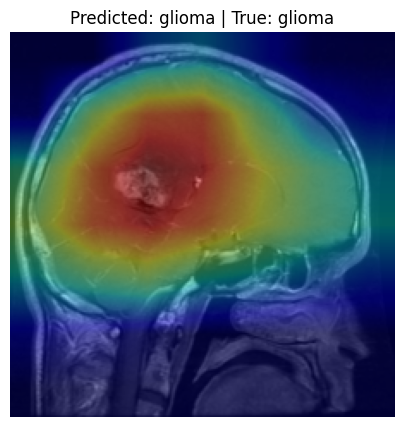

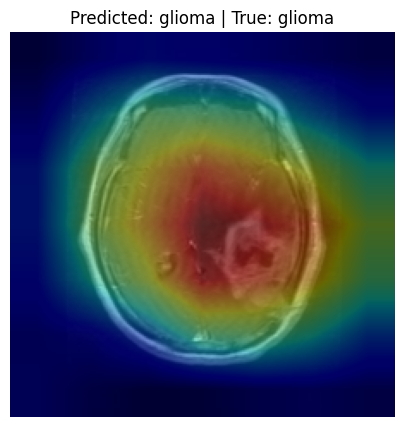

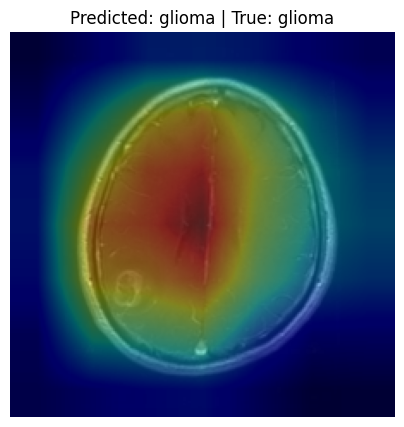

In [24]:
best_model_name = "ResNet50 Deeper Fine-Tuning"
best_model = load_model(best_model_name, MODEL_PATHS[best_model_name])

target_layer = best_model.layer4[-1]
gradcam = GradCAM(best_model, target_layer)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for idx in range(4):
    sample_image, sample_label = test_dataset[idx]
    input_image = sample_image.unsqueeze(0).to(DEVICE)

    cam, predicted_class = gradcam.generate(input_image)

    display_image = sample_image.cpu() * std + mean
    display_image = torch.clamp(display_image, 0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(display_image.permute(1, 2, 0))
    plt.imshow(cam, cmap="jet", alpha=0.4)
    plt.title(f"Predicted: {CLASS_NAMES[predicted_class]} | True: {CLASS_NAMES[sample_label]}")
    plt.axis("off")
    plt.show()

## 10) Evaluation Summary

This notebook evaluates multiple deep learning models for brain tumor classification using MRI images, including a baseline CNN, MobileNetV2 variants, and ResNet50 variants.

### Dataset

The evaluation is performed on a held-out test set containing 1000 MRI images across four classes: glioma, meningioma, no_tumor, and pituitary. All images are preprocessed using the same resizing and normalization pipeline used during training.

### Evaluation Metrics

The models are evaluated using multiple performance metrics:
- Accuracy
- Precision (weighted)
- Recall (weighted)
- F1-score (weighted)
- ROC-AUC (one-vs-rest multiclass)

Confusion matrices, ROC curves, and Grad-CAM visualization are also used to support model interpretation and error analysis.

### Results Summary

Fine-tuned transfer learning models clearly outperformed the baseline CNN. The strongest performance was achieved by the ResNet50 Deeper Fine-Tuning model, showing that unfreezing deeper ResNet50 layers improved feature adaptation to MRI images.

### Best Model

The ResNet50 Deeper Fine-Tuning model achieved the highest overall performance with an accuracy of 0.9890, F1-score of 0.9890, and AUC of 0.9994.

### Conclusion

Overall, ResNet50 Deeper Fine-Tuning was the best-performing model in this evaluation. The results show that fine-tuning pretrained convolutional neural networks can significantly improve brain tumor MRI classification compared with training a CNN from scratch.